#### 로지스틱 회귀로 와인 분류하기

In [1]:
import pandas as pd

In [2]:
wine = pd.read_csv('../Data/wine.csv')
wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [3]:
wine.tail()

,alcohol,sugar,pH,class
6492,11.2,1.6,3.27,1.0
6493,9.6,8.0,3.15,1.0
6494,9.4,1.2,2.99,1.0
6495,12.8,1.1,3.34,1.0
6496,11.8,0.8,3.26,1.0


In [5]:
# class의 종류를 파악   (종류를 파악할때는 unique)
wine['class'].unique()

array([0., 1.])

In [7]:
# class 빈도 수 파악
wine['class'].value_counts()

class
1.0    4898
0.0    1599
Name: count, dtype: int64

> 0 : Red Wine, 1 : White Wine

In [8]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [9]:
wine.shape

(6497, 4)

In [13]:
# 기본 통계량
wine.describe()
# sugar 가 평균 / 중앙값이 차이남. 현재 평균이 더 큰 값이므로 데이터들이 큰 쪽으로 치우친 상태

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


여기까진 항상 봐야 함. (필수)

#### Feature 와 Target

In [17]:
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()   # 숫자 데이터이기 때문에 굳이 pandas 쓸 필요 없음. numpy로 감
target = wine['class'].to_numpy()

In [19]:
data[:5]

array([[9.4 , 1.9 , 3.51],
       [9.8 , 2.6 , 3.2 ],
       [9.8 , 2.3 , 3.26],
       [9.8 , 1.9 , 3.16],
       [9.4 , 1.9 , 3.51]])

In [23]:
target[:5]

array([0., 0., 0., 0., 0.])

#### Train 과 Test

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        data,
        target,
        test_size=0.2,
        random_state=42
    )

In [26]:
print("train : ", train_input.shape)
print("test : ", test_input.shape)

train :  (5197, 3)
test :  (1300, 3)


#### 로지스틱 회귀이므로 표준화를 하기

In [28]:
from sklearn.preprocessing import StandardScaler   # 표준화

In [30]:
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)   # 학습한 거 기준으로 해야함

#### 로지스틱 회귀 모델

In [31]:
from sklearn.linear_model import LogisticRegression

In [33]:
lr = LogisticRegression()    # 괄호 안에 넣는 거에 따라 정확도가 달라짐
lr.fit(train_scaled, train_target)
print("Train : ", lr.score(train_scaled, train_target))
print("Test : ", lr.score(test_scaled, test_target))

Train :  0.7808350971714451
Test :  0.7776923076923077


In [39]:
# 가중치와 편차 구하기
print(lr.coef_, lr.intercept_)   # pH 의 기울기가 -가 나옴. => -pH가 나오는 건 문제상황

[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


class = 0.51268071 * alcohol + 1.67335441 * sugar - 0.68775646 * pH + 1.81773456

In [40]:
train_scaled   # 살펴보면 pH 부분에 - 가 나옴

array([[ 0.01376574,  0.4646116 , -0.16888369],
       [ 1.60871671, -0.70299854,  0.26967864],
       [ 1.10504798, -0.70299854,  1.20945505],
       ...,
       [-0.82568214,  0.0267578 ,  0.14437512],
       [-0.82568214,  0.52716215, -0.23153545],
       [-0.82568214, -0.57789745,  1.83597265]], shape=(5197, 3))

----
#### 결정트리(Decision Tree)
 : 선형회귀나 kNN 처럼 전처리 과정이 필요 없다.

##### Decision Tree 를 이용한 모델의 생성

In [41]:
from sklearn.tree import DecisionTreeClassifier  # 분류할 거니까 classifier

In [45]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_input, train_target)
print("Train : ", dt.score(train_input, train_target))
print("Test : ", dt.score(test_input, test_target))     # 과대적합

Train :  0.996921300750433
Test :  0.8584615384615385


#### 시각화

In [47]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [ ]:
plt.figure(figsize=(10,7))

plot_tree(dt)

plt.show()

# 그래프 징그러워서 지움

> 맨 위의 단계를 root node 라고 하고 맨 마지막 단계는 leaf node 라고 한다.  (단어는 알아야 함)   
시간이 너무 많이 걸리고 단계가 너무 복잡하다.

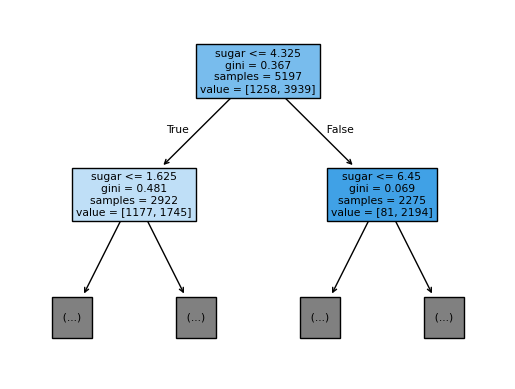

In [52]:
# decision tree의 단계(depth) 를 단순하게 하자
plt.figure()
plot_tree(
    dt,
    max_depth=1,
    filled=True,
    feature_names=['alcohol', 'sugar', 'pH']
)
plt.show()

> 양성(1) 일수록 파란색으로 표시된다.    
루트노드(root node)에서 sugar <= 4.325 이면 왼쪽으로 이동하고 아니면 오른쪽으로 이동한다.    
총 갯수가 5197개 인데 true 인 노드는 2922 개 이고, false 인 노드는 2275 개 이다.    
gini : 지니 불순도(Gini Impurity) 가 0이 나올 때를 순수노드라고 한다. (0 일수록 순수함)    
leaf node 가 순수 노드인 건 좋으나 이때 과대적합이 발생한다.    
따라서 적절한 max_depth 를 찾는 것이 중요하다.

#### 가지치기(Tree Pruning)
- max_depth 의 parameter 값을 조절.
- Decision Tree 의 과대 적합을 막는다.
- 선형회귀처럼 규제를 사용할 수 없다.

In [63]:
dt = DecisionTreeClassifier(
    max_depth=3     # 이게 과대적합이면서 차이가 5% 이내가 되도록 값을 넣어봄. 3부터 시작해서 넣어봄. => 이걸 for 문 돌리면 쉽게 출력 가능.
)
dt.fit(train_input, train_target)
print("Train : ", dt.score(train_input, train_target))
print("Test : ", dt.score(test_input, test_target))

Train :  0.8454877814123533
Test :  0.8415384615384616


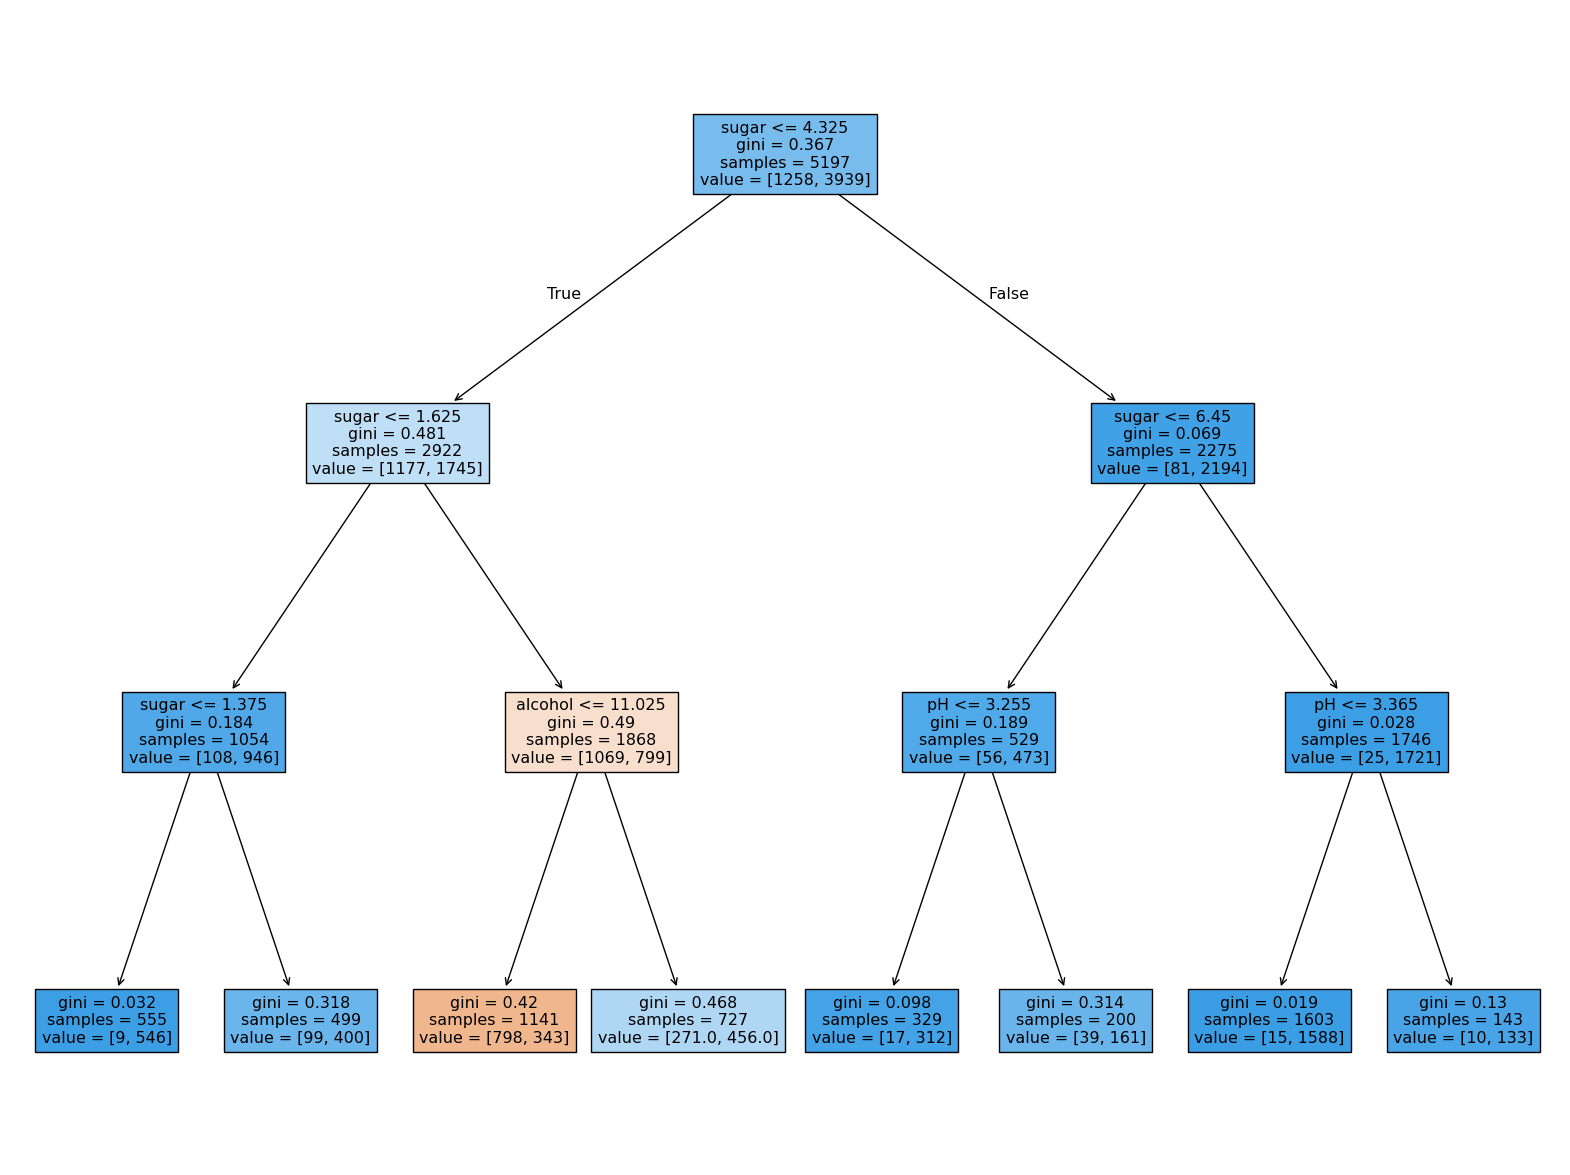

In [64]:
plt.figure(figsize=(20,15))
plot_tree(
    dt,
    filled=True,
    feature_names=['alcohol', 'sugar', 'pH']
)
plt.show()

In [ ]:
# 특성 중요도
dt.feature_importances_    # sugar 가 제일 크므로, 얘가 레드와인 / 화이트 와인 구분하는 데 중요한 요소라는 것.

array([0.12345626, 0.86862934, 0.0079144 ])

> alcohol, sugar, pH 의 순으로 특성중요도가 출력되며 이 중 sugar가 제일 중요한 요소로 작동된다는 것을 알 수 있다.

In [66]:
dt = DecisionTreeClassifier(
    min_impurity_decrease=0.0005  # 노드룰 분할하는 기준인 최소 불순도를 0.05% 로 결정
)
dt.fit(train_input, train_target)
print("Train : ", dt.score(train_input, train_target))
print("Test : ", dt.score(test_input, test_target))

Train :  0.8874350586877044
Test :  0.8615384615384616


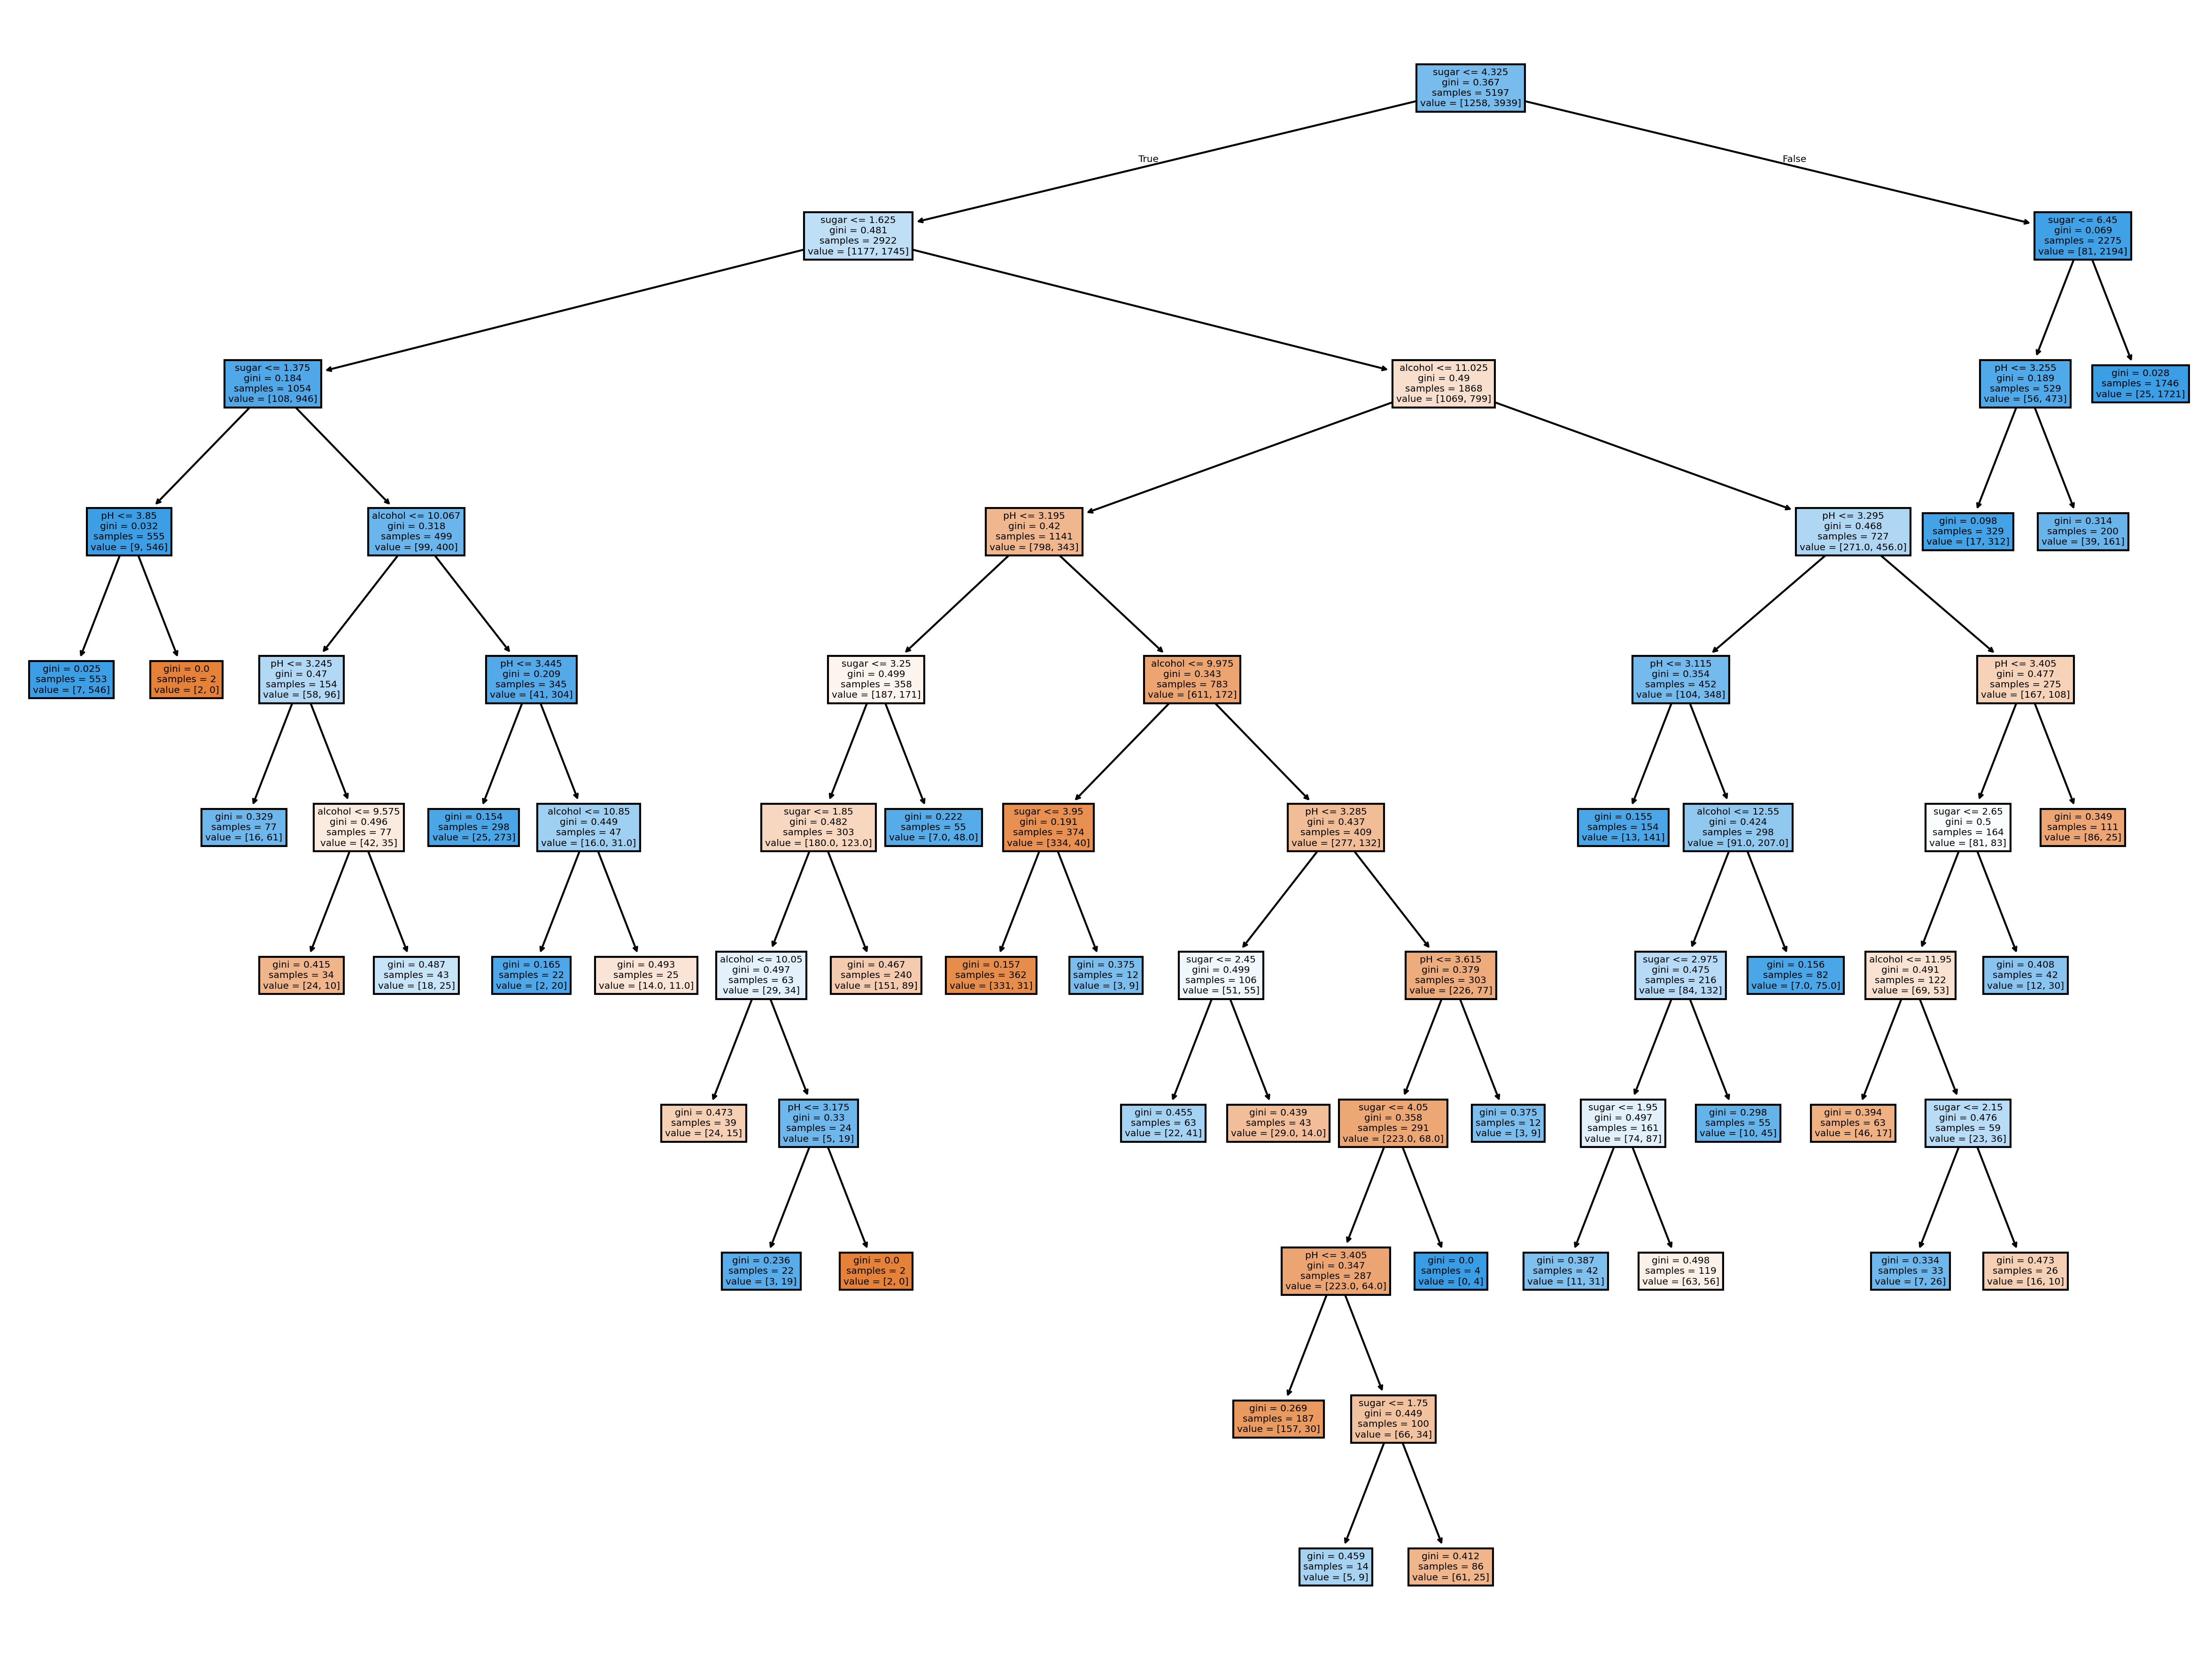

In [68]:
plt.figure(figsize=(20,15), dpi = 300)
plot_tree(
    dt,
    filled=True,
    feature_names=['alcohol', 'sugar', 'pH']
)
plt.savefig("../Data/wine.jpg")   # 파일로 저장하는 거. 해상도는 위에 figure의 dpi 임
plt.show()